In [1]:
import torch
import torch.nn as nn
import numpy as np

from functions import loadData, expand_mean, CAMELSrun, visualization, backtest, standardtest, print_model_weights_and_biases, permutation_importance

In [ ]:
def createModel(x_shape, y_shape):
    model = nn.Sequential(
        nn.Linear(x_shape, 32),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(16, y_shape)
    )

    # Summary to see the architecture
    print(model)
    return model

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

In [3]:
df, X, Y = CAMELSrun('04045500', 3, 7, 'Flow+1', True)

print(X.shape[0])

c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


34


In [4]:
model = createModel(X.shape[0], 1)

Sequential(
  (0): Linear(in_features=34, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=16, out_features=1, bias=True)
)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

print(torch.cuda.is_available())  # Should print True
print(torch.cuda.device_count())  # Should print the number of GPUs available
print(torch.cuda.get_device_name(0))  # Should print the name of your GPU


model.to(device)  # Move model to GPU
print(torch.cuda.memory_allocated(device=0))  # Shows allocated memory
print(torch.cuda.memory_reserved(device=0))   # Shows reserved memory

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU is available.
True
1
NVIDIA GeForce RTX 4060 Laptop GPU
8704
2097152


In [6]:
predictions, datetime1 = backtest(df, model, X, Y, 150, 365, 60, None, device)
y_pred = predictions["prediction"]
y_test = predictions["actual"]

y_pred = np.maximum(y_pred, 0)  # Ensure no negative predictions
y_pred = np.minimum(y_pred, np.max(y_test) * 1.1)  # Cap predictions at 10% above max value of y_test

Epoch 1/150, Loss: 1.1900957611699898
Epoch 2/150, Loss: 1.0290981239328783
Epoch 3/150, Loss: 0.947359866152207
Epoch 4/150, Loss: 0.8731411236027876
Epoch 5/150, Loss: 0.6604859220484892
Epoch 6/150, Loss: 0.518037041494002
Epoch 7/150, Loss: 0.3660309376815955
Epoch 8/150, Loss: 0.262929014240702
Epoch 9/150, Loss: 0.15748697301993766
Epoch 10/150, Loss: 0.10731959311912458
Epoch 11/150, Loss: 0.08859181450679898
Epoch 12/150, Loss: 0.0839687567204237
Epoch 13/150, Loss: 0.07524751623471577
Epoch 14/150, Loss: 0.05734696169383824
Epoch 15/150, Loss: 0.07424743830536802
Epoch 16/150, Loss: 0.08897255337797105
Epoch 17/150, Loss: 0.054464632257198296
Epoch 18/150, Loss: 0.05500742855171362
Epoch 19/150, Loss: 0.06502448425938685
Epoch 20/150, Loss: 0.09354159003123641
Epoch 21/150, Loss: 0.05930134917919835
Epoch 22/150, Loss: 0.04752155548582474
Epoch 23/150, Loss: 0.061336423348014556
Epoch 24/150, Loss: 0.0497587596376737
Epoch 25/150, Loss: 0.06074555575226744
Epoch 26/150, Loss: 

MAE: 67.7 m3/s
MSE: 10538.35 m3/s
RMSE: 102.66 m3/s
MAPE: 0.12%
Accuracy: 99.88%
R2: 0.9853


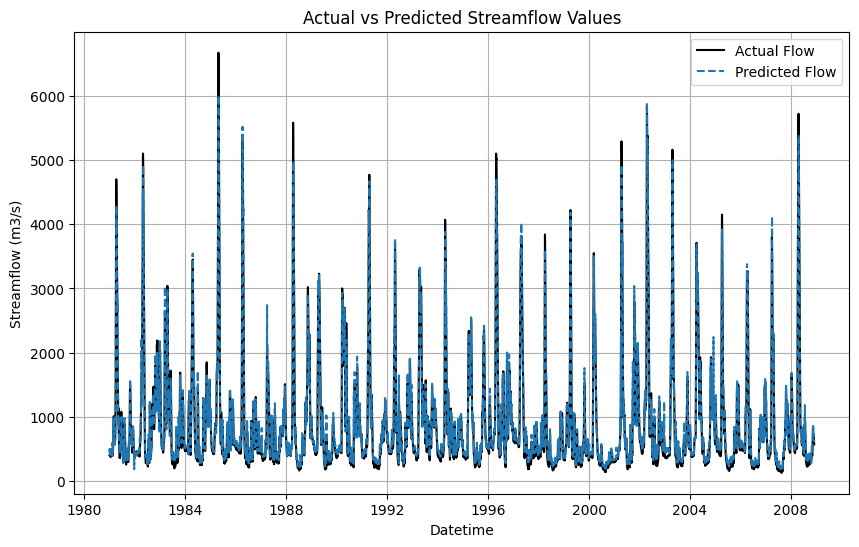

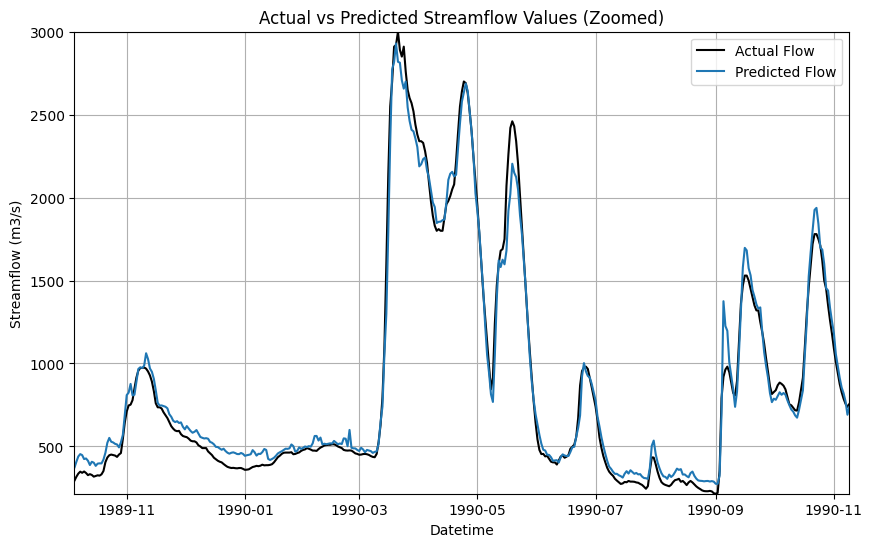

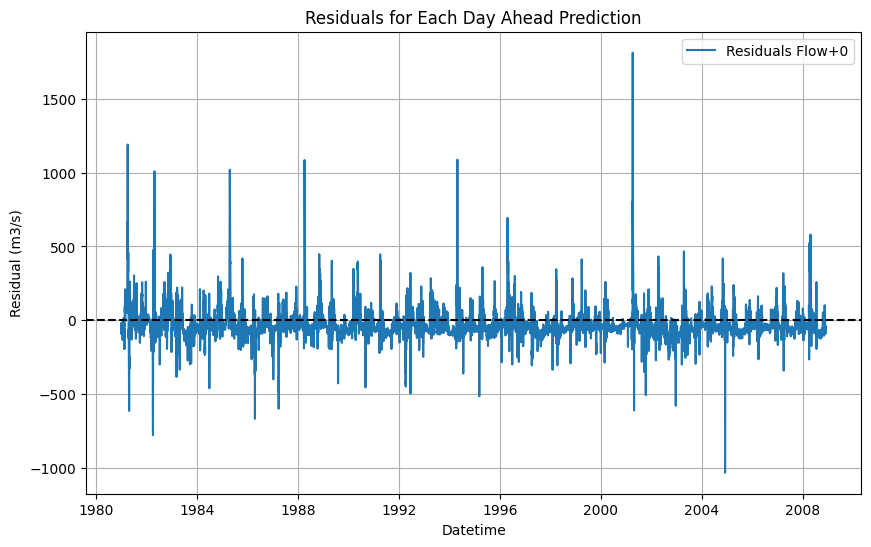

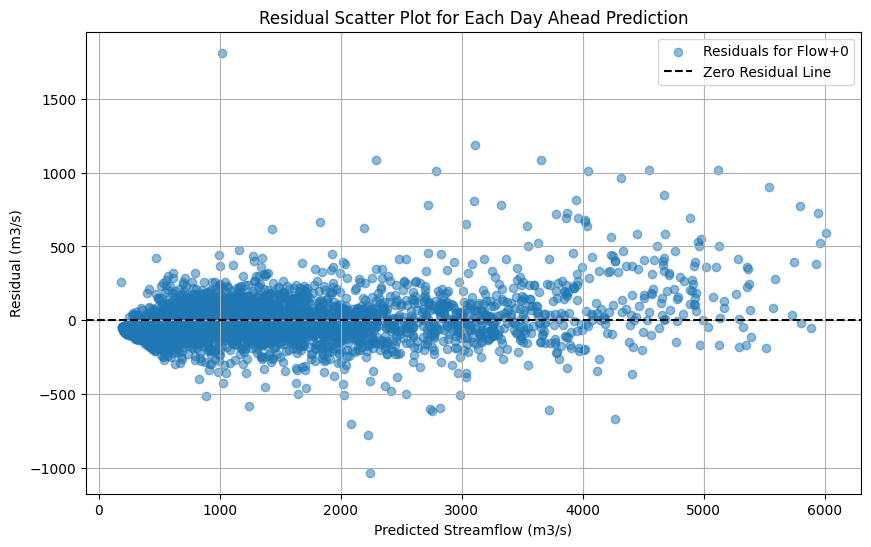

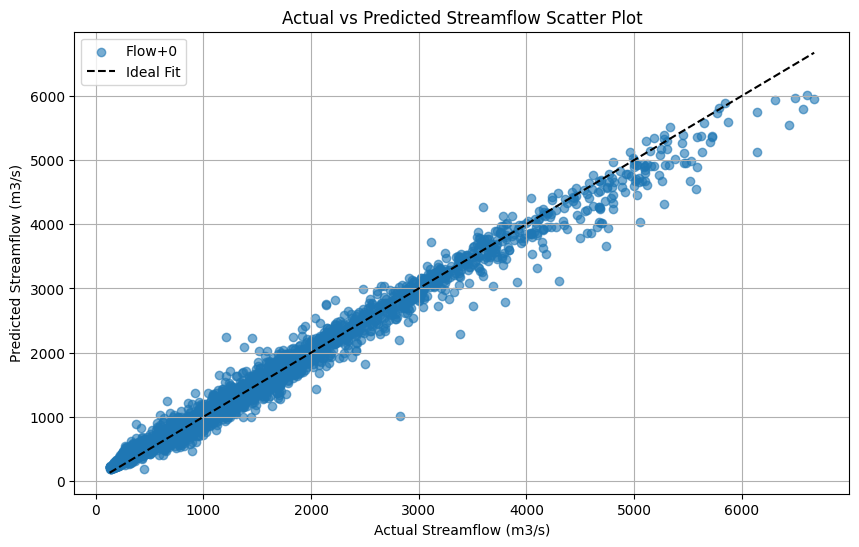

0.weight: torch.Size([32, 34])
tensor([[-0.3464,  0.1204, -0.1279,  ...,  0.0225, -0.1663, -0.1203],
        [ 0.3746,  0.0257, -0.0487,  ..., -0.0819, -0.0050, -0.0819],
        [ 0.3863, -0.0882,  0.0438,  ...,  0.0625, -0.0060, -0.1854],
        ...,
        [-0.5991, -0.0189, -0.0988,  ..., -0.1259,  0.1273, -0.0108],
        [-1.0924,  0.0121, -0.0531,  ...,  0.0428,  0.1922,  0.1294],
        [-1.3193, -0.0202, -0.0657,  ..., -0.0593, -0.0694,  0.1145]],
       device='cuda:0')
0.bias: torch.Size([32])
tensor([ 1.1482, -0.7564, -0.9061, -0.5808, -0.4471, -0.7183,  0.1625, -0.6241,
         0.5022, -0.6795,  0.3371,  0.2252, -0.7765, -0.7617, -0.7663,  0.2511,
        -0.7670,  1.0085,  0.3054, -0.7497, -0.6727, -0.7151, -0.5360, -0.7968,
        -0.5960, -0.7321,  0.2506, -0.8019, -0.5319,  0.9929,  0.0717,  0.8508],
       device='cuda:0')
3.weight: torch.Size([16, 32])
tensor([[ 4.0494e-02, -5.1977e-01, -7.7275e-01, -2.3291e+00, -1.4557e+00,
         -4.0400e-01, -2.6281e-02, -

In [7]:
visualization(datetime1, y_pred, y_test, 3200,3600)
print_model_weights_and_biases(model)

In [8]:
df, X, Y = CAMELSrun('13340000', 3, 7, 'Flow+1', False)

c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


In [9]:
predictions1, datetime2 = backtest(df, model, X, Y, 150, 365, 60, None, device)

y_pred1 = predictions1["prediction"]
y_test1 = predictions1["actual"]

y_pred1 = np.maximum(y_pred1, 0)  # Ensure no negative predictions1
y_pred1 = np.minimum(y_pred1, np.max(y_test1) * 1.1)  # Cap predictions1 at 10% above max value of y_test

Epoch 1/150, Loss: 0.07010164946162452
Epoch 2/150, Loss: 0.05715826634938518
Epoch 3/150, Loss: 0.050446233712136745
Epoch 4/150, Loss: 0.04579591017682105
Epoch 5/150, Loss: 0.041837355199580394
Epoch 6/150, Loss: 0.04074222967028618
Epoch 7/150, Loss: 0.04083486755068103
Epoch 8/150, Loss: 0.04201944909679393
Epoch 9/150, Loss: 0.036775784101337194
Epoch 10/150, Loss: 0.03175007272511721
Epoch 11/150, Loss: 0.03418028564192355
Epoch 12/150, Loss: 0.03187613973083595
Epoch 13/150, Loss: 0.03529270284343511
Epoch 14/150, Loss: 0.04271015121291081
Epoch 15/150, Loss: 0.029703066451475024
Epoch 16/150, Loss: 0.03466806731497248
Epoch 17/150, Loss: 0.03484063199721277
Epoch 18/150, Loss: 0.036617809208109975
Epoch 19/150, Loss: 0.025141010332542162
Epoch 20/150, Loss: 0.03274047592033943
Epoch 21/150, Loss: 0.024693001216898363
Epoch 22/150, Loss: 0.03080367064103484
Epoch 23/150, Loss: 0.02777517323071758
Epoch 24/150, Loss: 0.035530616296455264
Epoch 25/150, Loss: 0.025158821178289752


MAE: 1215.3 m3/s
MSE: 4752258.24 m3/s
RMSE: 2179.97 m3/s
MAPE: 0.29%
Accuracy: 99.713%
R2: 0.9546


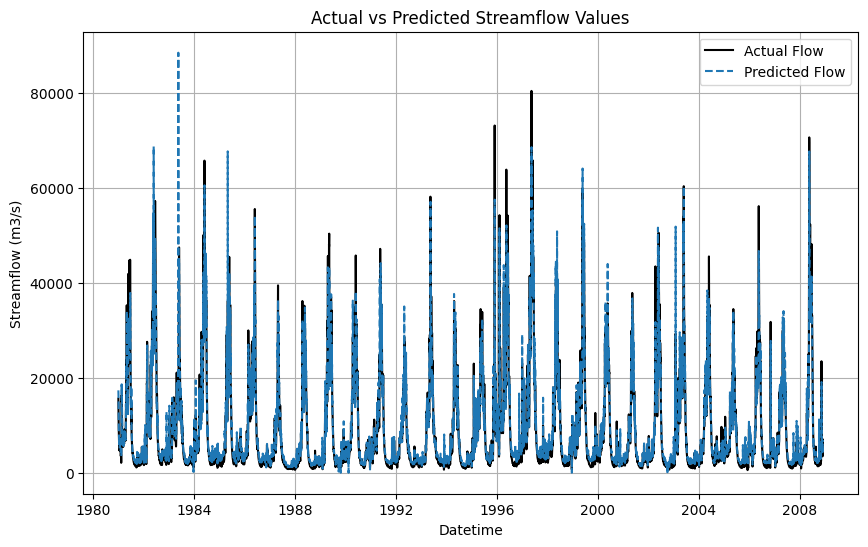

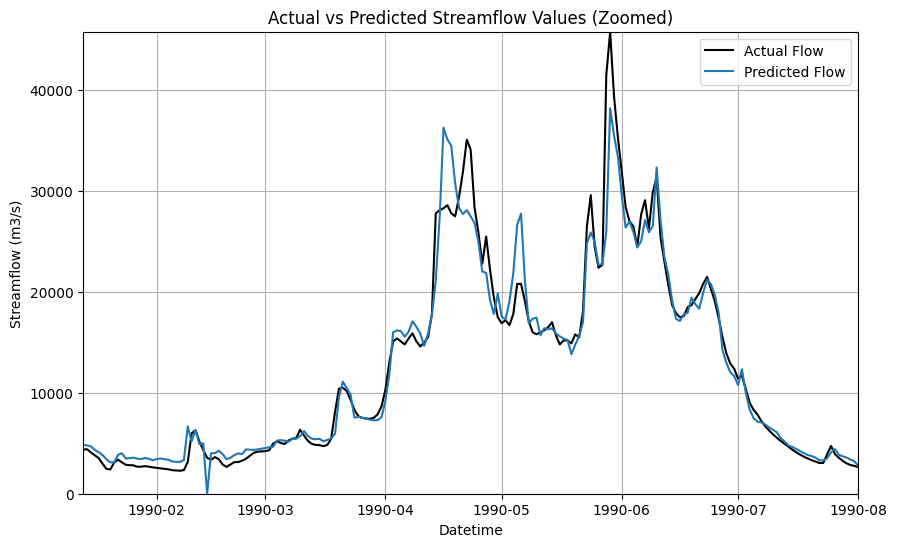

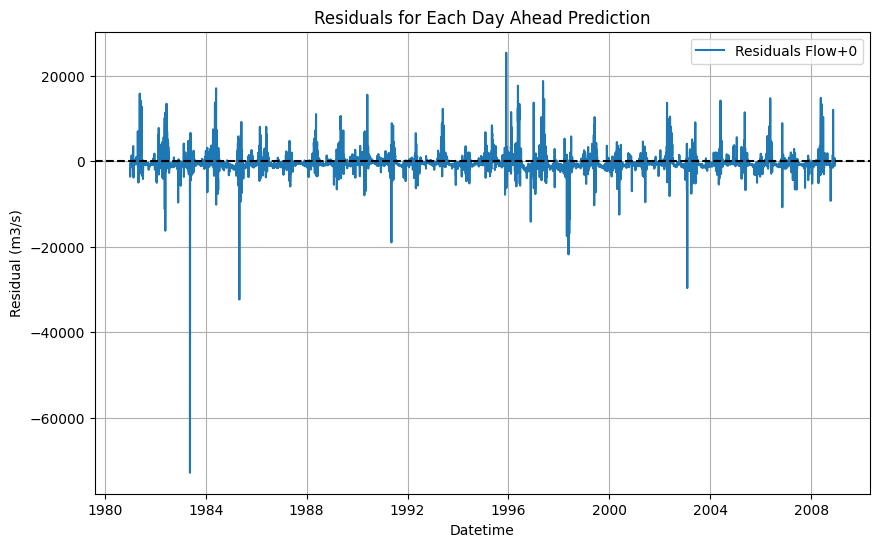

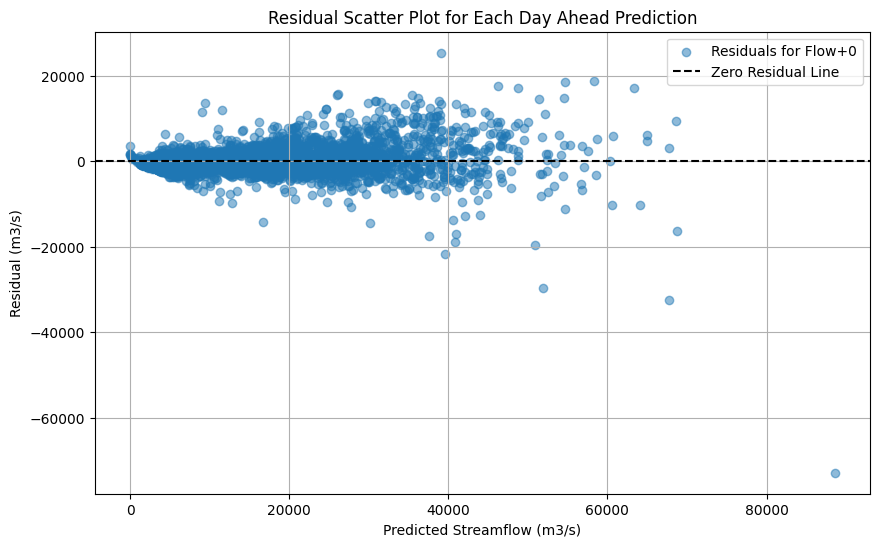

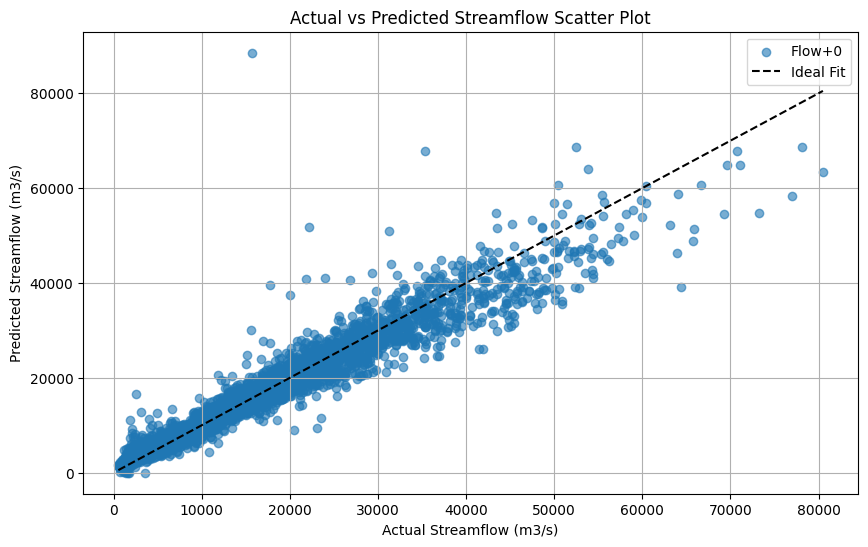

0.weight: torch.Size([32, 34])
tensor([[-0.4253, -0.0334, -0.1582,  ...,  0.0996, -0.0318, -0.1258],
        [ 0.0381, -0.0277,  0.1370,  ..., -0.1361, -0.1046, -0.1082],
        [ 0.0966, -0.1610,  0.6052,  ...,  0.2290, -0.2176, -0.3542],
        ...,
        [-0.6623, -0.0620, -0.2335,  ..., -0.0701,  0.2859,  0.0958],
        [-1.3971, -0.0719, -0.4257,  ...,  0.0761,  0.1105,  0.1132],
        [-1.7844, -0.0326, -0.0993,  ...,  0.0657, -0.0142, -0.0026]],
       device='cuda:0')
0.bias: torch.Size([32])
tensor([ 1.5437, -1.4609, -1.4286, -1.1524, -1.1778, -1.2709,  0.4588, -1.1594,
         0.7365, -1.2105,  0.7091,  0.5510, -1.4156, -1.5335, -1.1769,  0.3046,
        -1.3801,  1.4189,  0.3622, -1.0955, -1.0680, -1.1869, -1.0925, -1.6409,
        -1.0613, -1.5504,  0.2463, -1.2751, -0.4287,  1.3708,  0.2487,  1.4315],
       device='cuda:0')
3.weight: torch.Size([16, 32])
tensor([[ 6.0704e-02,  3.1113e-01,  1.4932e-01, -2.8265e+00, -9.3861e-01,
         -1.4939e+00, -4.3843e-02, -

In [10]:
visualization(datetime2, y_pred1, y_test1, 3300, 3500)
print_model_weights_and_biases(model)

In [11]:
df, X, Y = CAMELSrun('05131500', 3, 7, 'Flow+2', False)

predictions2, datetime3 = backtest(df, model, X, Y, 150, 365, 60, None, device)

y_pred2 = predictions2["prediction"]
y_test2 = predictions2["actual"]

y_pred2 = np.maximum(y_pred2, 0)  # Ensure no negative predictions2
y_pred2 = np.minimum(y_pred2, np.max(y_test2) * 1.1)  # Cap predictions2 at 10% above max value of y_test


c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


Epoch 1/150, Loss: 0.11796990471581618
Epoch 2/150, Loss: 0.14329846544812122
Epoch 3/150, Loss: 0.11368101090192795
Epoch 4/150, Loss: 0.0882394570702066
Epoch 5/150, Loss: 0.09004219357545178
Epoch 6/150, Loss: 0.09073073432470362
Epoch 7/150, Loss: 0.09442839996578793
Epoch 8/150, Loss: 0.06860801437869668
Epoch 9/150, Loss: 0.07088816538453102
Epoch 10/150, Loss: 0.0736013287678361
Epoch 11/150, Loss: 0.0776538357604295
Epoch 12/150, Loss: 0.05383481450068454
Epoch 13/150, Loss: 0.04279202789378663
Epoch 14/150, Loss: 0.07625824872714777
Epoch 15/150, Loss: 0.049079956176380314
Epoch 16/150, Loss: 0.0607842766524603
Epoch 17/150, Loss: 0.04813436736973623
Epoch 18/150, Loss: 0.039100634943073
Epoch 19/150, Loss: 0.055385905473182596
Epoch 20/150, Loss: 0.051765671310325466
Epoch 21/150, Loss: 0.04510457293751339
Epoch 22/150, Loss: 0.05533943026481817
Epoch 23/150, Loss: 0.053802004627262555
Epoch 24/150, Loss: 0.044642846643303834
Epoch 25/150, Loss: 0.03555651940405369
Epoch 26/1

MAE: 304.56 m3/s
MSE: 552877.22 m3/s
RMSE: 743.56 m3/s
MAPE: 0.57%
Accuracy: 99.434%
R2: 0.7908


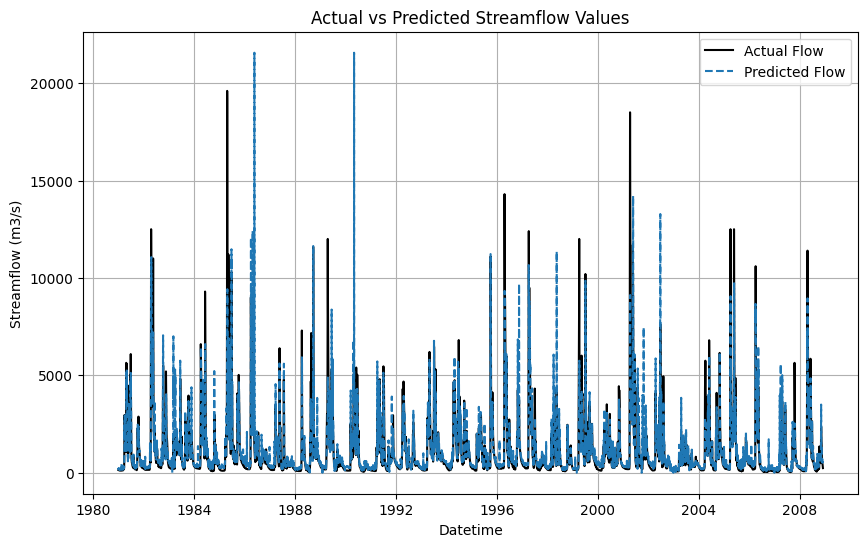

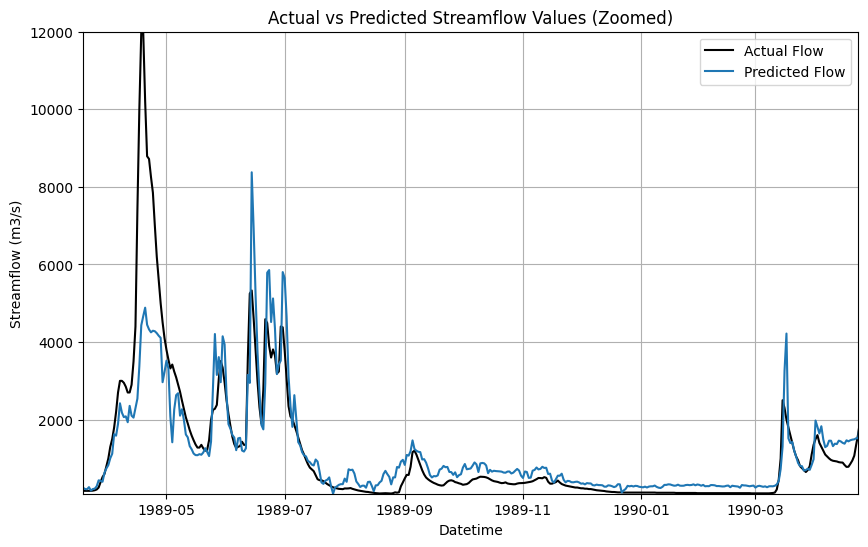

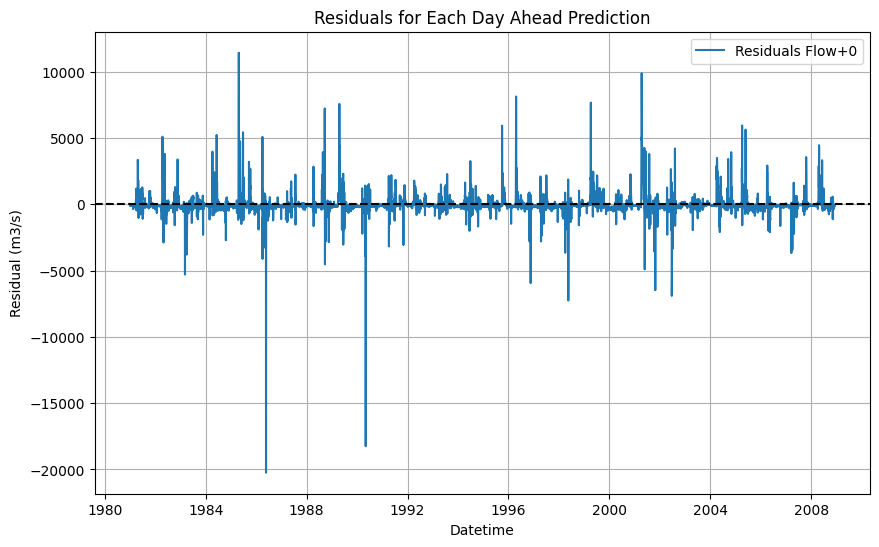

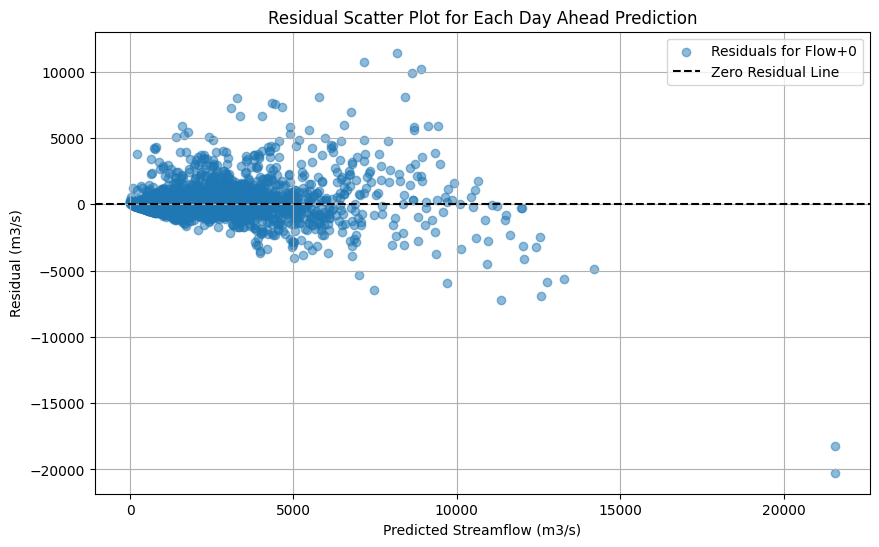

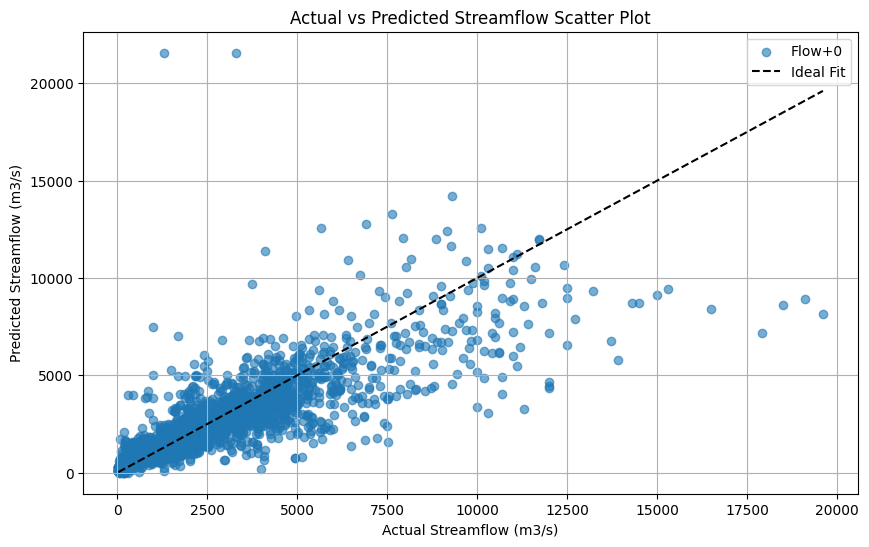

0.weight: torch.Size([32, 34])
tensor([[-4.5463e-01,  4.4199e-01, -5.7284e-01,  ...,  3.6299e-01,
          3.1352e-01,  2.8036e-01],
        [-3.9179e-01, -6.7058e-01,  5.7817e-02,  ..., -3.1793e-01,
         -2.8153e-01,  2.6139e-01],
        [-8.9975e-01, -8.8398e-02,  2.5518e-01,  ...,  4.1478e-01,
          1.3660e-01, -8.8063e-02],
        ...,
        [-6.9958e-01,  2.5091e-01, -1.8896e-01,  ..., -1.3230e-01,
          2.2121e-01,  1.7915e-01],
        [-2.2482e+00,  1.2675e-01, -2.2921e-01,  ...,  5.7188e-02,
          1.7714e-01,  1.0617e-01],
        [-2.5521e+00,  8.3039e-03,  2.3145e-03,  ..., -9.1867e-02,
         -2.0648e-01,  5.2952e-04]], device='cuda:0')
0.bias: torch.Size([32])
tensor([ 2.0139, -1.0025, -1.7212, -1.9109, -1.7640, -2.0240,  1.2896, -1.8261,
         1.4777, -2.1578,  0.7701,  1.0715, -1.2278, -1.9789, -2.2500,  0.4385,
        -2.2695,  1.8579,  0.9939, -1.4378, -1.8626, -1.9599, -1.8589, -1.8606,
        -1.9833, -1.1425,  0.8310, -1.5196, -0.6930,  1

In [12]:
visualization(datetime3, y_pred2, y_test2, 3000, 3400)
print_model_weights_and_biases(model)

c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


Epoch 1/150, Loss: 0.20427713667352995
Epoch 2/150, Loss: 0.14114938800533613
Epoch 3/150, Loss: 0.13055366758878031
Epoch 4/150, Loss: 0.11645513245215018
Epoch 5/150, Loss: 0.08771197063227494
Epoch 6/150, Loss: 0.08616511958340804
Epoch 7/150, Loss: 0.07088363675090174
Epoch 8/150, Loss: 0.07202558832553525
Epoch 9/150, Loss: 0.0653620408847928
Epoch 10/150, Loss: 0.07459284365177155
Epoch 11/150, Loss: 0.042934573255479336
Epoch 12/150, Loss: 0.052793489303439856
Epoch 13/150, Loss: 0.05413676549990972
Epoch 14/150, Loss: 0.05258825266112884
Epoch 15/150, Loss: 0.04774066526442766
Epoch 16/150, Loss: 0.041223559994250536
Epoch 17/150, Loss: 0.05304779034728805
Epoch 18/150, Loss: 0.03485249743486444
Epoch 19/150, Loss: 0.04384721163660288
Epoch 20/150, Loss: 0.0503590718532602
Epoch 21/150, Loss: 0.037621618093301855
Epoch 22/150, Loss: 0.03919694246724248
Epoch 23/150, Loss: 0.03366488621880611
Epoch 24/150, Loss: 0.03542981079469124
Epoch 25/150, Loss: 0.04502986604347825
Epoch 2

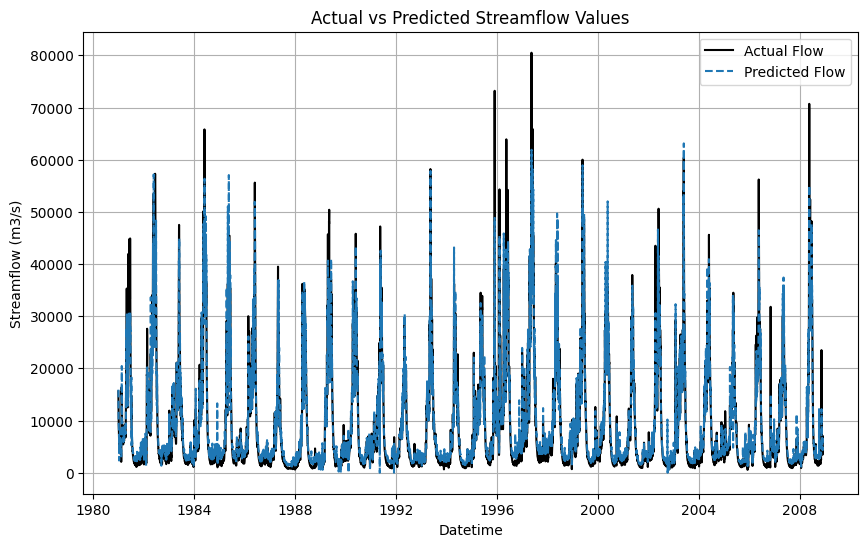

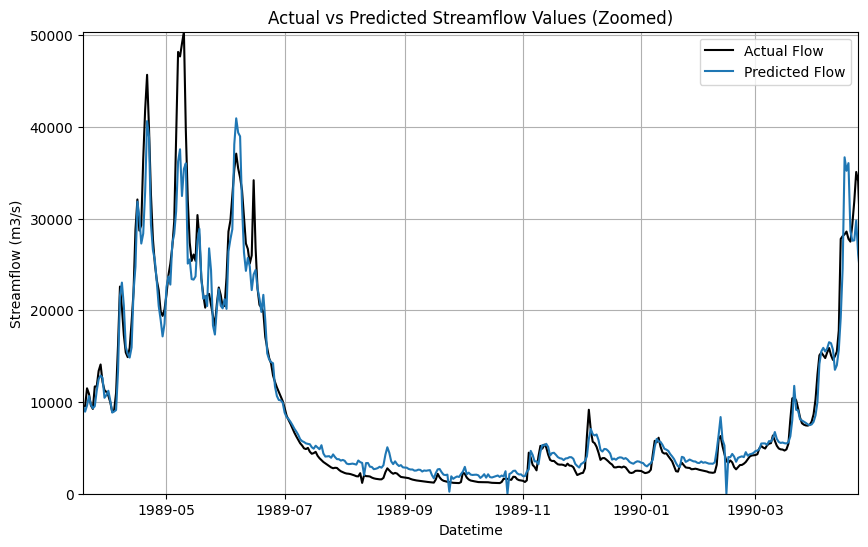

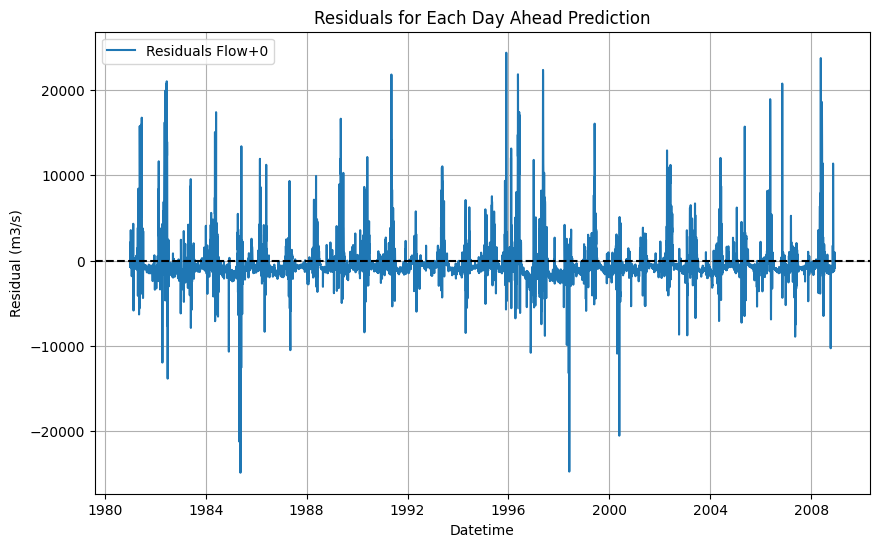

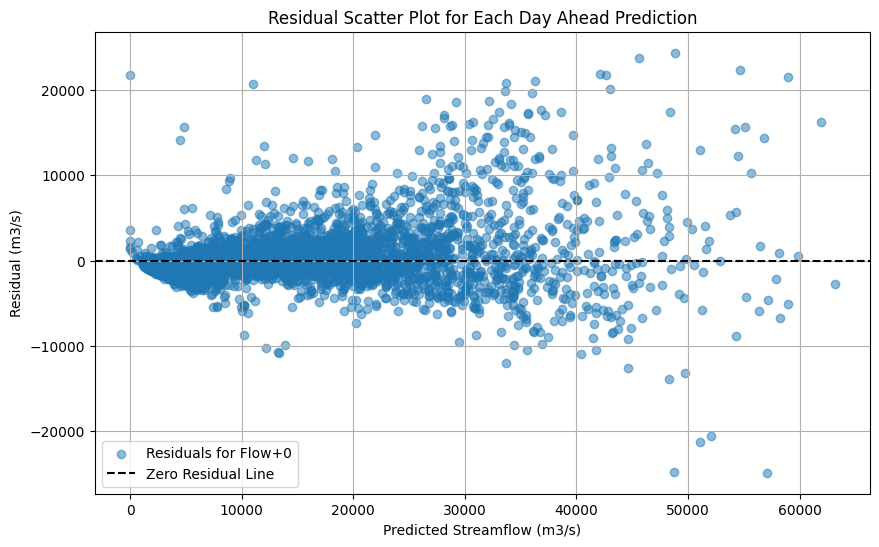

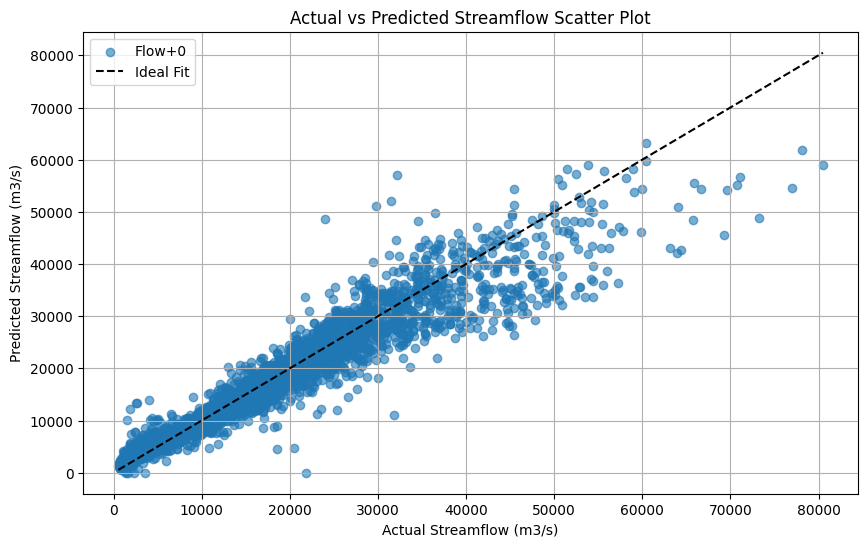

0.weight: torch.Size([32, 34])
tensor([[-0.5309, -0.1799, -0.0914,  ...,  0.1516,  0.0848,  0.1766],
        [-0.7926, -1.1766,  0.0458,  ..., -0.1306, -0.0409,  0.4020],
        [-1.3094,  0.0303,  0.4139,  ...,  0.1837, -0.3351, -0.2632],
        ...,
        [-0.8102,  0.0634, -0.2588,  ..., -0.0631,  0.2152,  0.2196],
        [-2.2942, -0.1655, -0.4430,  ...,  0.0159,  0.2146,  0.1591],
        [-2.8065, -0.0300, -0.0910,  ..., -0.0244, -0.0426,  0.0306]],
       device='cuda:0')
0.bias: torch.Size([32])
tensor([ 2.4242, -0.3978, -0.5299, -2.3985, -2.1080, -2.8198,  1.5414, -2.1863,
         2.1000, -3.0115,  1.1487,  1.0240, -0.2327, -2.0822, -2.6957,  0.5112,
        -2.2294,  2.0675,  1.0058, -0.8391, -2.2720, -2.4085, -2.0641, -1.9217,
        -2.5548, -1.1602,  1.2509, -2.2773, -0.0992,  2.2212,  0.6629,  2.1594],
       device='cuda:0')
3.weight: torch.Size([16, 32])
tensor([[ 1.3734e-02,  7.9486e-02,  1.3855e-01,  5.7299e-02, -3.9129e-01,
         -3.2255e-01, -3.1361e-02, -

In [13]:
df, X, Y = CAMELSrun('13340000', 3, 7, 'Flow+1', False)

predictions3, datetime4 = backtest(df, model, X, Y, 150, 365, 60, None, device)

y_pred3 = predictions3["prediction"]
y_test3 = predictions3["actual"]

y_pred3 = np.maximum(y_pred3, 0)  # Ensure no negative predictions3
y_pred3 = np.minimum(y_pred3, np.max(y_test3) * 1.1)  # Cap predictions3 at 10% above max value of y_test

visualization(datetime4, y_pred3, y_test3, 3000, 3400)
print_model_weights_and_biases(model)

In [19]:
import datetime as dt

current_time = dt.datetime.now().strftime("%Y%m%d-%H%M%S")
print(current_time)


torch.save(model.state_dict(), f"./models/MLP_150_365_60_{current_time}.pth")


20250324-175937
